# EDA y Preparación de Datos — Corpus Salvadoreño de Toxicidad

**Análisis del Discurso de Odio en Redes Sociales en El Salvador**
Universidad de El Salvador · Facultad de Ingeniería y Arquitectura · Escuela de Sistemas Informáticos

Julio Enrique De La Quadra Mata · Cristian Antonio Escalante Hernández · Willian Alexander Chávez Servellón

---

## Objetivo del notebook

Auditar el corpus manual, decidir y aplicar una estrategia de preparación de datos
compatible con el *fine-tuning* de **mBERT** y **XLM-R**, y producir los conjuntos
`train / val / test` estratificados.

## Principio rector: preservación máxima

Este notebook **no** aplica el preprocesamiento clásico de NLP (minúsculas, quitar
tildes, corregir ortografía, quitar puntuación, eliminar stopwords, lematizar).
Esa receta pertenece a modelos de bolsa de palabras (TF-IDF + SVM). Con
Transformers preentrenados es contraproducente, por tres razones:

1. **Desalineación con el preentrenamiento.** mBERT (`bert-base-multilingual-cased`)
   y XLM-R aprendieron sus representaciones sobre español real: con tildes,
   mayúsculas y puntuación. El tokenizador subword ya modela esas formas.
   Quitarlas empuja la entrada fuera de la distribución de preentrenamiento.

2. **La "falta de ortografía" es señal, no ruido.** En contenido tóxico, escribir
   `pvto` o `4güevo` suele ser evasión deliberada de filtros de moderación. El
   propio léxico del proyecto documenta 2,035 variantes por ese motivo. Corregirlas
   borra exactamente el fenómeno que queremos detectar.

3. ***Train/serve skew*.** En producción la API recibirá texto crudo. Cualquier
   transformación aplicada al entrenamiento debe replicarse idénticamente en
   inferencia. Cuanto más corto el pipeline, menor el riesgo de divergencia. Por eso
   la normalización vive en `src/features/normalization.py` y **la importan tanto
   este notebook como el endpoint de FastAPI**.

Lo que sí se normaliza es lo que **no es lingüístico**: codificación Unicode,
caracteres invisibles, whitespace, y la identidad de personas (PII).

## Regla de oro

`data/raw/` es **inmutable**. Todo lo que este notebook produce se escribe en
`data/interim/` y `data/processed/`.

## 0. Configuración

In [1]:
import sys, os, re, json, warnings, unicodedata, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Raíz del proyecto (funciona desde notebooks/ y desde la raíz)
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

RAW       = ROOT / "data" / "raw"
INTERIM   = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
FIGURAS   = ROOT / "reports" / "figures"
for d in (INTERIM, PROCESSED, FIGURAS):
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

# Estilo de figuras: paleta sobria, apta para impresión en el documento final
sns.set_theme(style="whitegrid", context="notebook")
PALETA = {
    "No Tóxico":          "#4C9F70",
    "Lenguaje Ofensivo":  "#E8A33D",
    "Discurso de Odio":   "#C1554E",
    "Amenazas/Violencia": "#7B3F61",
}
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.edgecolor": "#666666", "figure.facecolor": "white",
})

def guardar(fig, nombre):
    ruta = FIGURAS / f"{nombre}.png"
    fig.savefig(ruta, facecolor="white")
    print(f"figura guardada -> {ruta.relative_to(ROOT)}")
    return ruta

print("Proyecto:", ROOT)

Proyecto: /sessions/bold-practical-shannon/mnt/proyecto


In [2]:
from src.features.normalization import (
    normalizar, normalizar_agresivo, perfil_texto,
    RE_MENCION, RE_URL, RE_HASHTAG,
)
from src.data.label_mapping import (
    CLASES_CANONICAS, MAPEO_CLASES, MAPEO_SUBCLASES,
    REQUIERE_REVISION, mapear_clase, mapear_subclase, LABEL2ID, ID2LABEL,
)
import emoji

print("Clases canónicas:", CLASES_CANONICAS)

Clases canónicas: ['No Tóxico', 'Lenguaje Ofensivo', 'Discurso de Odio', 'Amenazas/Violencia']


## 1. Carga y perfil general

Se cargan los tres archivos crudos. Es importante separar sus roles desde el inicio:

| Archivo | Rol | ¿Entrena el modelo? |
|---|---|---|
| `corpus_salvadoreno.csv` | Publicaciones reales de X y Facebook, anotadas | **Sí** |
| `lexicon_salvadoreno.csv` | Entradas de jerga y variantes ortográficas | **No** — recurso lingüístico |
| `lexicon_emojis.csv` | Catálogo de emojis con uso discriminatorio | **No** — recurso lingüístico |

El léxico **no debe mezclarse** con el corpus para entrenar. Son palabras aisladas
fuera de contexto; introducirlas como ejemplos enseñaría al modelo a clasificar por
presencia de término, que es precisamente el sesgo que un Transformer debería
superar respecto a un enfoque de diccionario. Su uso correcto es análisis de
cobertura y *data augmentation* controlada.

In [3]:
corpus = pd.read_csv(RAW / "corpus_salvadoreno.csv", dtype=str, keep_default_na=False, na_values=[""])
lexico = pd.read_csv(RAW / "lexicon_salvadoreno.csv", dtype=str, keep_default_na=False, na_values=[""])

print(f"corpus : {corpus.shape[0]:,} filas x {corpus.shape[1]} columnas")
print(f"léxico : {lexico.shape[0]:,} filas")
corpus.head(3)

corpus : 3,104 filas x 23 columnas
léxico : 2,035 filas


,ID,Responsable,Plataforma,Fecha_Recolección,Texto_Original,URL_Original,Usuario_ID_Anonimizado,Clase_Toxicidad,Subclase_Toxicidad,Grupos_Afectados,...,Contexto_Politico,Confianza_Clasificador,Notas_Etiquetador,Validado,Validador,Fecha_Validacion,Acuerdo_Validador,Razon_Desacuerdo,Cohen_Kappa,Listo_Entrenamiento
0,1,Willian,X,2026-07-13,Mi madrecita a sus más de 60 años volvió a emp...,https://x.com/favitapd/status/2076484944218439972,USER_001,No Tóxico,N/A,N/A,...,NO,0.95,"Emprendimiento familiar, comida salvadoreña, s...",NO,NaN,NaN,NaN,N/A,NaN,NO
1,2,Willian,X,2026-07-13,Comparte tu arte y tu nacionalidad Aprovechand...,https://x.com/Lau37930618/status/2052084944634...,USER_002,No Tóxico,N/A,N/A,...,NO,0.9,"Compartir arte y nacionalidad salvadoreña, ton...",NO,NaN,NaN,NaN,N/A,NaN,NO
2,3,Willian,X,2026-07-13,En Los Naranjos siempre es primavera. #ElSalva...,https://x.com/Bymoonhunter/status/191047753117...,USER_003,No Tóxico,N/A,N/A,...,NO,0.95,"Paisaje/naturaleza de El Salvador, sin agresión.",NO,NaN,NaN,NaN,N/A,NaN,NO


In [4]:
# --- Perfil de completitud por columna ---
perfil = pd.DataFrame({
    "no_nulos":   corpus.notna().sum(),
    "%_nulos":    (corpus.isna().mean() * 100).round(1),
    "n_unicos":   corpus.nunique(),
    "ejemplo":    [corpus[c].dropna().iloc[0] if corpus[c].notna().any() else "—" for c in corpus.columns],
})
perfil["ejemplo"] = perfil["ejemplo"].astype(str).str.slice(0, 45)
perfil

,no_nulos,%_nulos,n_unicos,ejemplo
ID,3104,0.0,3104,1
Responsable,3104,0.0,3,Willian
Plataforma,3104,0.0,2,X
Fecha_Recolección,3104,0.0,61,2026-07-13
Texto_Original,3104,0.0,3068,Mi madrecita a sus más de 60 años volvió a em
URL_Original,3104,0.0,3049,https://x.com/favitapd/status/207648494421843
Usuario_ID_Anonimizado,3104,0.0,3104,USER_001
Clase_Toxicidad,3104,0.0,16,No Tóxico
Subclase_Toxicidad,3104,0.0,55,N/A
Grupos_Afectados,3103,0.0,292,N/A


### Lectura del perfil

Tres columnas del esquema están **vacías al 100%**: `Validador`, `Fecha_Validacion`
y `Cohen_Kappa`. Una cuarta, `Validado`, está rellena — pero con `"NO"` en las 3,104
filas. Dicho de otro modo: **ninguna fila ha pasado por validación cruzada entre
anotadores**, y el perfil de trabajo del proyecto fija κ ≥ 0.60 como criterio de
calidad. Se retoma en la sección 9.

## 2. Auditoría de integridad

Antes de mirar distribuciones hay que saber si el archivo es confiable: formatos de
fecha, duplicados, y consistencia del esquema.

In [5]:
print("=== FECHAS ===")
fechas_raw = corpus["Fecha_Recolección"]
mal_formato = fechas_raw[~fechas_raw.str.match(r"^\d{4}-\d{2}-\d{2}$", na=False)]
print(f"fuera del formato ISO YYYY-MM-DD: {len(mal_formato)}")
print(mal_formato.value_counts().head(10).to_string())

corpus["fecha"] = pd.to_datetime(fechas_raw, format="mixed", errors="coerce")
print(f"\nno parseables: {corpus['fecha'].isna().sum()}")
print(f"rango: {corpus['fecha'].min():%Y-%m-%d} a {corpus['fecha'].max():%Y-%m-%d}")

=== FECHAS ===
fuera del formato ISO YYYY-MM-DD: 1
Fecha_Recolección
2026-7-15    1

no parseables: 0
rango: 2026-05-24 a 2026-07-27


In [6]:
print("=== DUPLICADOS ===")
dup_exactos = corpus.duplicated(subset=["Texto_Original"], keep=False)
print(f"filas con texto duplicado exacto: {dup_exactos.sum()}")

# Duplicado "casi exacto": mismo texto tras normalizar espacios y mayúsculas.
# Sólo para DETECTAR — no se altera el texto que va al modelo.
clave = (corpus["Texto_Original"].astype(str)
         .str.normalize("NFKC").str.lower()
         .str.replace(r"\s+", " ", regex=True).str.strip())
dup_norm = clave.duplicated(keep=False)
print(f"filas con texto duplicado tras normalizar: {dup_norm.sum()}")

# ¿Los duplicados tienen etiquetas distintas? Eso indicaría desacuerdo silencioso.
conflictos = (corpus.assign(_k=clave)[dup_norm]
              .groupby("_k")["Clase_Toxicidad"].nunique())
conflictos = conflictos[conflictos > 1]
print(f"\nduplicados con ETIQUETAS EN CONFLICTO: {len(conflictos)}")
if len(conflictos):
    ej = corpus.assign(_k=clave)[clave.isin(conflictos.index)]
    display(ej[["_k", "Responsable", "Clase_Toxicidad"]].sort_values("_k").head(12))

=== DUPLICADOS ===
filas con texto duplicado exacto: 67
filas con texto duplicado tras normalizar: 72

duplicados con ETIQUETAS EN CONFLICTO: 0


In [7]:
print("=== IDENTIFICADORES ===")
print(f"IDs duplicados: {corpus['ID'].duplicated().sum()}")
print(f"URLs duplicadas: {corpus['URL_Original'].dropna().duplicated().sum()}")
print(f"\nUsuarios anonimizados distintos: {corpus['Usuario_ID_Anonimizado'].nunique():,}")
top_u = corpus["Usuario_ID_Anonimizado"].value_counts().head(5)
print("Usuarios más frecuentes:\n" + top_u.to_string())

=== IDENTIFICADORES ===
IDs duplicados: 0
URLs duplicadas: 55

Usuarios anonimizados distintos: 3,104
Usuarios más frecuentes:
Usuario_ID_Anonimizado
USER_3088    1
USER_3087    1
USER_3086    1
USER_3085    1
USER_3084    1


> **Por qué importa la concentración de usuarios.** Si un puñado de cuentas aporta
> muchas filas, los *splits* aleatorios dejarán publicaciones del mismo autor en
> train y en test. El modelo puede aprender el estilo del autor en lugar de la
> toxicidad, e inflar la métrica. Se controla en la sección 10.

## 3. El problema de las etiquetas

La taxonomía del proyecto define **4 clases**. El archivo contiene **16 valores
distintos**. La pregunta no es "cómo lo limpio" sino "**por qué pasó**", porque la
respuesta determina la corrección adecuada.

In [8]:
vc = corpus["Clase_Toxicidad"].value_counts()
print(f"valores distintos en Clase_Toxicidad: {len(vc)}\n")
print(vc.to_string())

valores distintos en Clase_Toxicidad: 16

Clase_Toxicidad
Lenguaje Ofensivo          1033
Discurso de odio            672
No Tóxico                   538
Amenazas/Violencia          501
discriminacion              104
racismo                      63
xenofobia                    63
clasismo                     55
religiofobia                 27
Insulto                      17
Discurso de Odio             12
antisemitismo                12
discriminacion_politica       3
violencia_psicologica         2
incitacion_odio               1
violencia_genero              1


In [9]:
# ¿Se distribuyen las anomalías al azar entre anotadores?
anomalas = ~corpus["Clase_Toxicidad"].isin(CLASES_CANONICAS + ["Discurso de odio"])
tabla = pd.crosstab(corpus["Responsable"], anomalas, normalize="index").mul(100).round(1)
tabla.columns = ["% canónicas", "% anómalas"]
display(tabla)

print("\nEtiquetas anómalas por anotador:")
print(pd.crosstab(corpus.loc[anomalas, "Clase_Toxicidad"],
                  corpus.loc[anomalas, "Responsable"]).to_string())

,% canónicas,% anómalas
Responsable,,
Cristian,100.0,0.0
Julio,65.9,34.1
Willian,100.0,0.0



Etiquetas anómalas por anotador:
Responsable              Julio
Clase_Toxicidad               
Insulto                     17
antisemitismo               12
clasismo                    55
discriminacion             104
discriminacion_politica      3
incitacion_odio              1
racismo                     63
religiofobia                27
violencia_genero             1
violencia_psicologica        2
xenofobia                   63


figura guardada -> reports/figures/01_etiquetas_crudas.png


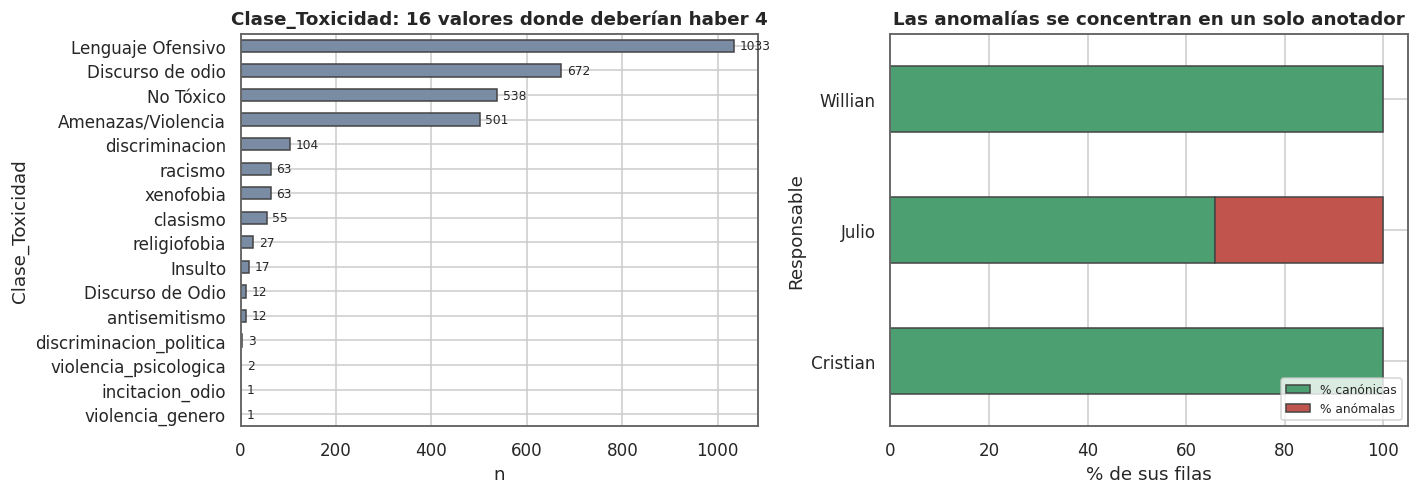

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

vc.plot(kind="barh", ax=axes[0], color="#7A8CA3", edgecolor="#444")
axes[0].invert_yaxis()
axes[0].set_title("Clase_Toxicidad: 16 valores donde deberían haber 4")
axes[0].set_xlabel("n")
for i, v in enumerate(vc.values):
    axes[0].text(v + 12, i, str(v), va="center", fontsize=8)

tabla.plot(kind="barh", stacked=True, ax=axes[1],
           color=["#4C9F70", "#C1554E"], edgecolor="#444")
axes[1].set_title("Las anomalías se concentran en un solo anotador")
axes[1].set_xlabel("% de sus filas")
axes[1].legend(loc="lower right", fontsize=8)
plt.tight_layout()
guardar(fig, "01_etiquetas_crudas")
plt.show()

### Diagnóstico

Las 348 filas anómalas provienen **íntegramente de un solo anotador**, que registró
el **nivel de subclase en la columna de clase**: anotó `racismo`, `xenofobia`,
`clasismo` donde el protocolo pedía `Discurso de Odio` en `Clase_Toxicidad` y el eje
de discriminación en `Subclase_Toxicidad`.

Esto **no es un error de tipeo**, es una **divergencia de protocolo entre
anotadores**. Tiene dos consecuencias:

1. La corrección no puede ser un `.str.title()`. Requiere un mapeo semántico
   explícito, documentado y auditable → `src/data/label_mapping.py`.
2. Es un indicio de que la **guía de anotación no fue suficientemente unívoca**.
   Debe corregirse antes de la ronda de validación cruzada, o el Kappa medirá
   discrepancia de protocolo en vez de discrepancia de criterio.

Adicionalmente aparece la colisión de mayúsculas `Discurso de odio` (672, dos
anotadores) vs `Discurso de Odio` (12, un anotador) — misma clase, dos grafías.

## 4. Consolidación a las 4 clases canónicas

**Criterio adoptado:** la clase se define por el *objeto* del ataque, no por su
*eje*. Un ataque a un grupo protegido es `Discurso de Odio`, independientemente de si
el eje es racial, nacional, religioso o corporal. El eje se preserva en
`Subclase_Toxicidad`, que es donde pertenece.

Los casos genuinamente ambiguos **no se asignan por defecto**: se apartan para
revisión humana. Son 7 filas; el coste de revisarlas es trivial y el coste de
introducir ruido en una clase minoritaria no lo es.

In [11]:
print("MAPEO APLICADO\n" + "=" * 62)
for k, v in sorted(MAPEO_CLASES.items(), key=lambda x: (x[1], x[0])):
    marca = "  " if k == v else "->"
    print(f"  {k:<28} {marca} {v}")

print("\nAPARTADAS PARA REVISIÓN MANUAL\n" + "=" * 62)
for k, motivo in REQUIERE_REVISION.items():
    n = (corpus['Clase_Toxicidad'] == k).sum()
    print(f"  {k}  (n={n})\n     {motivo}\n")

MAPEO APLICADO
  Amenazas/Violencia              Amenazas/Violencia
  Discurso de Odio                Discurso de Odio
  Discurso de odio             -> Discurso de Odio
  antisemitismo                -> Discurso de Odio
  clasismo                     -> Discurso de Odio
  discriminacion               -> Discurso de Odio
  racismo                      -> Discurso de Odio
  religiofobia                 -> Discurso de Odio
  xenofobia                    -> Discurso de Odio
  Insulto                      -> Lenguaje Ofensivo
  Lenguaje Ofensivo               Lenguaje Ofensivo
  No Tóxico                       No Tóxico

APARTADAS PARA REVISIÓN MANUAL
  discriminacion_politica  (n=3)
     La afiliación política no es categoría protegida en la mayoría de taxonomías de hate speech (Waseem & Hovy 2016; HatEval). Podría ser 'Lenguaje Ofensivo'. Decidir y documentar en la guía de anotación.

  incitacion_odio  (n=1)
     Frontera entre 'Discurso de Odio' y 'Amenazas/Violencia'. Depende de si ha

In [12]:
res = corpus["Clase_Toxicidad"].apply(mapear_clase)
corpus["clase"] = [r[0] for r in res]
corpus["revisar_manual"] = [r[1] for r in res]
corpus["subclase"] = corpus["Subclase_Toxicidad"].apply(mapear_subclase)

print(f"mapeadas automáticamente : {(~corpus['revisar_manual']).sum():,}")
print(f"apartadas para revisión  : {corpus['revisar_manual'].sum():,}")
print()
print(corpus.loc[~corpus["revisar_manual"], "clase"].value_counts().to_string())

# Se exporta la cola de revisión para que el equipo la resuelva a mano.
cola = corpus[corpus["revisar_manual"]][
    ["ID", "Responsable", "Clase_Toxicidad", "Subclase_Toxicidad", "Texto_Original"]
]
cola.to_csv(INTERIM / "cola_revision_etiquetas.csv", index=False, encoding="utf-8-sig")
print(f"\ncola de revisión -> data/interim/cola_revision_etiquetas.csv")
display(cola)

mapeadas automáticamente : 3,097
apartadas para revisión  : 7

clase
Lenguaje Ofensivo     1050
Discurso de Odio      1008
No Tóxico              538
Amenazas/Violencia     501

cola de revisión -> data/interim/cola_revision_etiquetas.csv


,ID,Responsable,Clase_Toxicidad,Subclase_Toxicidad,Texto_Original
2285,2286,Julio,violencia_genero,misoginia,Sali a ayudarle al vecino maje para que se vay...
2286,2287,Julio,incitacion_odio,Estigmatización cultural,esos maje que dicen wey hay que hacerles bully...
2292,2293,Julio,discriminacion_politica,Estigmatización cultural,Ya salen todas las focas pedorras diciendo que...
2321,2322,Julio,discriminacion_politica,Estigmatización cultural,Vaya.... Se nota que los izquierchangos no par...
2340,2341,Julio,violencia_psicologica,Estigmatización moral,"Tremendo fracasado, pense que era un meme pero..."
2394,2395,Julio,discriminacion_politica,Estigmatización cultural,Que yuca ha de ser en estos tiempos estar en l...
2540,2541,Julio,violencia_psicologica,Estigmatización moral,en el cielo no reciben basura


figura guardada -> reports/figures/02_clases_consolidadas.png


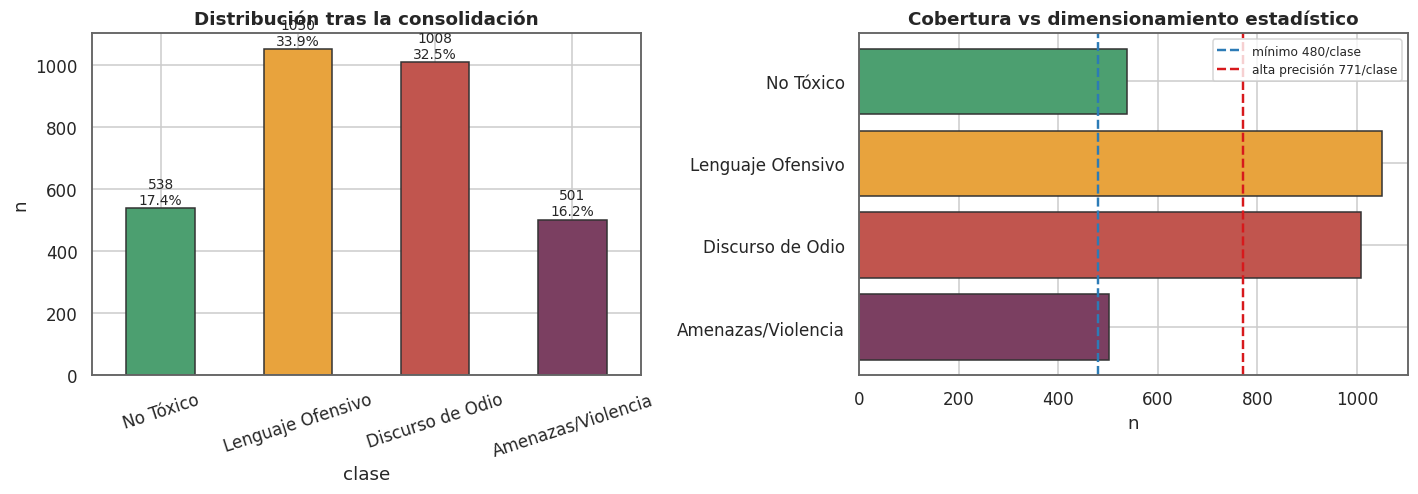

Ratio de desbalance máx/mín: 2.10x


In [13]:
antes = corpus["Clase_Toxicidad"].value_counts()
despues = corpus.loc[~corpus["revisar_manual"], "clase"].value_counts().reindex(CLASES_CANONICAS)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

despues.plot(kind="bar", ax=axes[0],
             color=[PALETA[c] for c in despues.index], edgecolor="#333")
axes[0].set_title("Distribución tras la consolidación")
axes[0].set_ylabel("n"); axes[0].tick_params(axis="x", rotation=18)
for i, v in enumerate(despues.values):
    axes[0].text(i, v + 15, f"{v}\n{v/despues.sum()*100:.1f}%", ha="center", fontsize=9)

# Objetivo de dimensionamiento del proyecto
objetivo_min, objetivo_alto = 480, 771
axes[1].barh(despues.index, despues.values,
             color=[PALETA[c] for c in despues.index], edgecolor="#333")
axes[1].axvline(objetivo_min,  color="#2C7BB6", ls="--", lw=1.6, label=f"mínimo {objetivo_min}/clase")
axes[1].axvline(objetivo_alto, color="#D7191C", ls="--", lw=1.6, label=f"alta precisión {objetivo_alto}/clase")
axes[1].set_title("Cobertura vs dimensionamiento estadístico")
axes[1].invert_yaxis(); axes[1].legend(fontsize=8); axes[1].set_xlabel("n")
plt.tight_layout()
guardar(fig, "02_clases_consolidadas")
plt.show()

ratio = despues.max() / despues.min()
print(f"Ratio de desbalance máx/mín: {ratio:.2f}x")

### Lectura del balance

El total supera el escenario de alta precisión del dimensionamiento, pero **la
cobertura por clase no es uniforme**. Con `Lenguaje Ofensivo` sobrerrepresentada y
`Amenazas/Violencia` por debajo del umbral, un modelo entrenado tal cual tenderá a
predecir la clase mayoritaria y el F1-macro caerá por la clase minoritaria.

Mitigaciones previstas en el perfil del proyecto, en orden de preferencia:

1. **`class_weight` en la función de pérdida** (`CrossEntropyLoss(weight=...)`) —
   sin coste de datos, primera opción.
2. **Recolección dirigida** de `Amenazas/Violencia` hasta ≥ 480 — la solución real.
3. **Data augmentation** con las variantes del léxico salvadoreño.
4. *Oversampling* — última opción: con Transformers y textos cortos favorece el
   sobreajuste por memorización.

> **Nota metodológica:** cualquier remuestreo se aplica **solo a `train`**. Aplicarlo
> antes del *split* filtra información y produce métricas infladas.

## 5. Auditoría de anonimización

El corpus es candidato a publicarse en un repositorio de GitHub público (exigido por
la rúbrica). Toda información que permita reidentificar a personas físicas debe
tratarse antes.

Se auditan tres superficies: menciones en el texto, URLs dentro del texto, y la
columna `URL_Original`.

In [14]:
txt = corpus["Texto_Original"].astype(str)

pii = pd.DataFrame({
    "@menciones en el texto":     [txt.str.contains(RE_MENCION, regex=True).sum()],
    "URLs dentro del texto":      [txt.str.contains(r"https?://", regex=True).sum()],
    "hashtags":                   [txt.str.contains(RE_HASHTAG, regex=True).sum()],
    "emails":                     [txt.str.contains(r"[\w.]+@[\w-]+\.\w+", regex=True).sum()],
    "posibles teléfonos SV":      [txt.str.contains(r"\b[267]\d{3}[\s-]?\d{4}\b", regex=True).sum()],
    "URL_Original con handle":    [corpus["URL_Original"].astype(str)
                                   .str.contains(r"(?:x|twitter)\.com/[A-Za-z0-9_]+/status", regex=True).sum()],
}).T.rename(columns={0: "n_filas"})
pii["%"] = (pii["n_filas"] / len(corpus) * 100).round(2)
display(pii)

print("\nEjemplos de URL_Original tal como están guardadas:")
for u in corpus["URL_Original"].dropna().head(4):
    print("  ", u)

,n_filas,%
@menciones en el texto,147,4.74
URLs dentro del texto,54,1.74
hashtags,293,9.44
emails,0,0.00
posibles teléfonos SV,3,0.10
URL_Original con handle,1542,49.68



Ejemplos de URL_Original tal como están guardadas:
   https://x.com/favitapd/status/2076484944218439972
   https://x.com/Lau37930618/status/2052084944634044786
   https://x.com/Bymoonhunter/status/1910477531171389706
   https://x.com/Edgard0Delgad0/status/1885699440620560641


### Hallazgo crítico

La columna `Usuario_ID_Anonimizado` contiene seudónimos (`USER_001`, …), pero la
columna **`URL_Original` conserva la URL real de la publicación**, que en X incluye
el *handle* de la cuenta en la propia ruta:

```
https://x.com/<handle>/status/<id>
```

La seudonimización queda **anulada**: cualquiera puede abrir la URL y obtener la
identidad. Publicar el CSV así equivale a publicar los usuarios sin anonimizar.

**Corrección adoptada** — separar en dos artefactos:

| Artefacto | Contenido | Destino |
|---|---|---|
| `data/processed/*.csv` | Texto normalizado, etiquetas, seudónimo. **Sin URL.** | Repositorio público |
| `data/interim/mapa_procedencia.csv` | `ID → URL_Original` | **Local. En `.gitignore`.** |

Se conserva la trazabilidad para el equipo (necesaria para reverificar anotaciones)
sin exponer identidades. Adicionalmente se guarda un hash SHA-256 truncado de la URL
en el dataset público: permite detectar duplicados entre *splits* sin revelar el origen.

### Sobre las menciones dentro del texto

Se **reemplazan por `@usuario`**, no se eliminan. La distinción importa: la
*presencia* de una mención distingue un ataque **dirigido a una persona** de una
afirmación general, y eso es señal predictiva legítima. Se borra la identidad, se
conserva la estructura sintáctica. Mismo criterio para URLs (`http://url`).

In [15]:
import hashlib

corpus["hash_origen"] = corpus["URL_Original"].fillna("").apply(
    lambda u: hashlib.sha256(u.encode()).hexdigest()[:16] if u else ""
)

mapa = corpus[["ID", "URL_Original", "hash_origen", "Usuario_ID_Anonimizado"]]
mapa.to_csv(INTERIM / "mapa_procedencia.csv", index=False, encoding="utf-8-sig")
print(f"mapa de procedencia (NO versionar) -> data/interim/mapa_procedencia.csv")
print(f"  {len(mapa):,} filas")

mapa de procedencia (NO versionar) -> data/interim/mapa_procedencia.csv
  3,104 filas


## 6. Emojis: estrategia y justificación empírica

Los emojis son la pregunta más interesante del preprocesamiento, porque cargan
significado real y los tokenizadores los tratan mal.

In [16]:
corpus["n_emojis"] = txt.apply(emoji.emoji_count)
corpus["tiene_emoji"] = corpus["n_emojis"] > 0

sub = corpus[~corpus["revisar_manual"]]
tasa = (sub.groupby("clase")["tiene_emoji"].agg(["sum", "mean", "count"])
        .reindex(CLASES_CANONICAS))
tasa.columns = ["textos_con_emoji", "tasa", "total"]
tasa["tasa_%"] = (tasa["tasa"] * 100).round(2)
display(tasa[["textos_con_emoji", "total", "tasa_%"]])

cont = collections.Counter()
for s in txt:
    for e in emoji.emoji_list(s):
        cont[e["emoji"]] += 1
print(f"\nemojis distintos: {len(cont)}   ocurrencias totales: {sum(cont.values())}")
for e, n in cont.most_common(12):
    print(f"  {n:>4}  {emoji.demojize(e, language='es')}")

,textos_con_emoji,total,tasa_%
clase,,,
No Tóxico,2,538,0.37
Lenguaje Ofensivo,190,1050,18.10
Discurso de Odio,3,1008,0.30
Amenazas/Violencia,0,501,0.00



emojis distintos: 105   ocurrencias totales: 491
   130  :cara_revolviéndose_de_la_risa:
    71  :cara_llorando_de_risa:
    38  :caca_con_ojos:
    22  :dedo_corazón_hacia_arriba_tono_de_piel_claro_medio:
    17  :cara_sonriendo_con_sudor_frío:
    16  :cara_de_payaso:
    13  :cara_cabreada:
    11  :dedo_corazón_hacia_arriba:
     7  :cara_de_bostezo:
     7  :cara_gritando_de_miedo:
     6  :dedo_corazón_hacia_arriba_tono_de_piel_oscuro_medio:
     5  :cara_sonriendo_con_gafas_de_sol:


figura guardada -> reports/figures/03_emojis.png


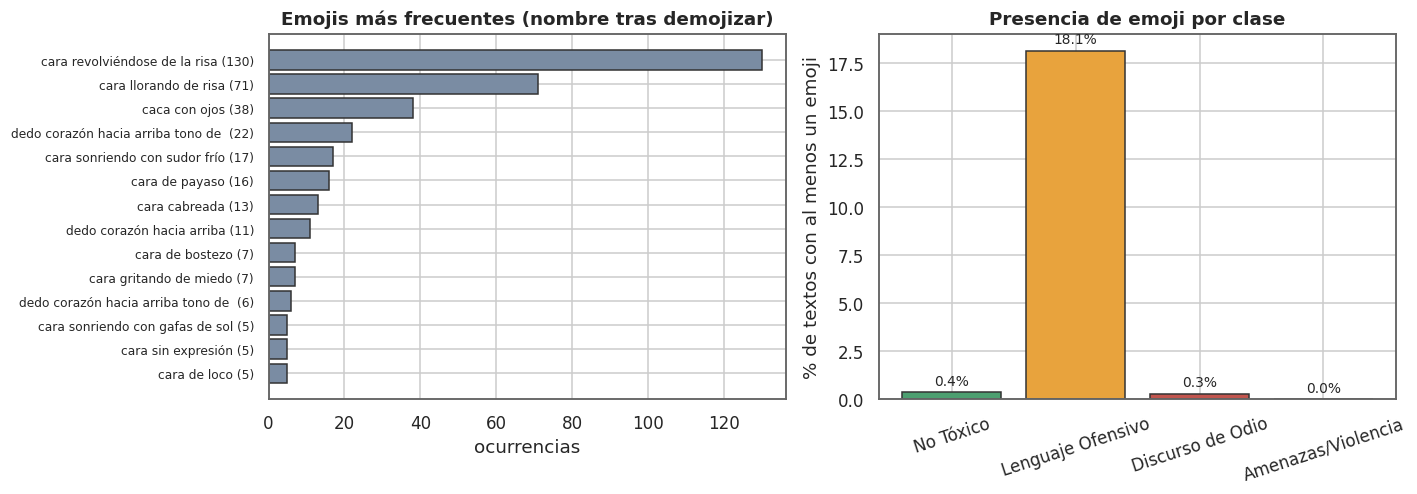

In [17]:
top = cont.most_common(14)

# Las etiquetas usan la descripción en español, no el glifo: matplotlib no
# dispone de fuente de emoji y dibujaría cuadros vacíos. De paso, muestra
# exactamente lo que verá el modelo tras la demojización.
def etiqueta_emoji(e):
    nombre = emoji.demojize(e, language="es", delimiters=("", "")).strip("_")
    nombre = re.sub(r"[\U0001F3FB-\U0001F3FF]", "", nombre)
    return nombre.replace("_", " ")[:34] if nombre else "(sin nombre)"

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].barh([f"{etiqueta_emoji(e)} ({n})" for e, n in top][::-1],
             [n for _, n in top][::-1], color="#7A8CA3", edgecolor="#333")
axes[0].set_title("Emojis más frecuentes (nombre tras demojizar)")
axes[0].set_xlabel("ocurrencias")
axes[0].tick_params(axis="y", labelsize=8)

t = tasa["tasa_%"].dropna()
axes[1].bar(t.index, t.values, color=[PALETA[c] for c in t.index], edgecolor="#333")
axes[1].set_title("Presencia de emoji por clase")
axes[1].set_ylabel("% de textos con al menos un emoji")
axes[1].tick_params(axis="x", rotation=18)
for i, v in enumerate(t.values):
    axes[1].text(i, v + 0.4, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
guardar(fig, "03_emojis")
plt.show()

### Por qué los emojis no son decorativos aquí

La presencia de emoji **no está distribuida al azar entre clases**: se concentra
fuertemente en `Lenguaje Ofensivo` y es casi nula en `No Tóxico`. Los más frecuentes
del corpus (🤣 😂 💩 🖕 🤡 😡 🤬) son marcadores de burla, desprecio y agresión.

Es decir: **el emoji es una variable predictiva**, no adorno. Descartarlos es
descartar señal. Y el catálogo del proyecto (`lexicon_emojis.csv`) documenta casos en
los que el emoji **es** el vehículo del odio — 🐒 + bandera nacional como
bestialización racial, 🧼 + 🇮🇱 como referencia al Holocausto — donde el texto
circundante puede ser inocuo.

In [18]:
# ¿Qué hace cada tokenizador con estos emojis?
# Requiere red (Hugging Face). Si no hay acceso, la celda lo reporta y sigue.
resultados_tok = None
try:
    from transformers import AutoTokenizer
    tok_mbert = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
    tok_xlmr  = AutoTokenizer.from_pretrained("xlm-roberta-base")

    filas = []
    for e, n in cont.most_common(30):
        fila = {"emoji": e, "frecuencia": n}
        for nombre, tk in [("mBERT", tok_mbert), ("XLM-R", tok_xlmr)]:
            piezas = tk.tokenize(e)
            unk = tk.unk_token
            fila[f"{nombre}_tokens"] = " ".join(piezas) if piezas else "(vacío)"
            fila[f"{nombre}_perdido"] = (len(piezas) == 0) or all(p == unk for p in piezas)
        filas.append(fila)
    resultados_tok = pd.DataFrame(filas)

    total = resultados_tok["frecuencia"].sum()
    for m in ["mBERT", "XLM-R"]:
        perdidos = resultados_tok.loc[resultados_tok[f"{m}_perdido"], "frecuencia"].sum()
        print(f"{m}: {perdidos}/{total} ocurrencias de emoji se pierden como UNK "
              f"({perdidos/total*100:.1f}%)")
    display(resultados_tok.head(20))
except Exception as e:
    print("Sin acceso a Hugging Face en este entorno.")
    print("Ejecutar esta celda en Colab o con red para obtener las cifras.")
    print("Detalle:", type(e).__name__)

Sin acceso a Hugging Face en este entorno.
Ejecutar esta celda en Colab o con red para obtener las cifras.
Detalle: ModuleNotFoundError


### Cómo trata cada modelo un emoji

| | mBERT (`bert-base-multilingual-cased`) | XLM-R (`xlm-roberta-base`) |
|---|---|---|
| Tokenizador | WordPiece, vocab ≈ 119k | SentencePiece/BPE, vocab ≈ 250k |
| Corpus de vocabulario | Volcados de Wikipedia (2018) | CommonCrawl / CC-100 (web) |
| Emojis en ese corpus | Prácticamente ninguno | Sí, texto web real |
| Resultado esperado | La mayoría → `[UNK]`, **señal perdida** | Los comunes se cubren; ZWJ, banderas y tonos de piel se fragmentan |

Wikipedia no usa emojis; CommonCrawl sí. De ahí la asimetría. Un `[UNK]` no es un
token neutro: colapsa 🤣, 💩 y 🖕 en el **mismo vector**, borrando toda distinción
entre burla, desprecio y agresión.

### Decisión: demojizar a español

```
"sos un 🤡"  →  "sos un :payaso:"
"te voy a 🖕🏼"  →  "te voy a :dedo_medio_hacia_arriba:"
```

Cuatro razones:

1. **Iguala el terreno entre modelos.** `:payaso:` se segmenta en subwords que ambos
   modelos conocen. La comparación mBERT vs XLM-R deja de estar contaminada por
   diferencias de cobertura de vocabulario y mide lo que queremos medir: capacidad
   de clasificación.
2. **Aprovecha el preentrenamiento en español.** El modelo ya tiene representación
   semántica de "payaso", "mierda", "dedo medio". El emoji crudo no activa nada.
3. **Consistencia con el baseline.** RoBERTuito (`pysentimiento`), uno de los
   baselines del proyecto, aplica esta misma conversión. Sin ella, la comparación
   sería injusta.
4. **Es reversible.** Nada se destruye: `texto_original` queda intacto en el
   dataset. `texto_modelo` es una columna paralela.

**Modificadores de tono de piel:** se eliminan. 🖕🏼 y 🖕🏾 expresan lo mismo; el
modificador solo fragmenta el token y dispersa la señal entre variantes.

### Verificación pendiente en la fase de modelado

Esta decisión es una **hipótesis fundamentada, no un resultado**. El dataset se
exporta con `texto_original`, `texto_modelo` (demojizado) y `texto_agresivo`
(control), de modo que en la Etapa II se pueda medir el F1 de cada variante y
**reportar la diferencia con evidencia**. Eso es lo que convierte una decisión de
preprocesamiento en un aporte del trabajo.

In [19]:
ejemplos = corpus[corpus["tiene_emoji"]]["Texto_Original"].head(6).tolist()
for t_ in ejemplos:
    print("CRUDO   :", t_[:110])
    print("MODELO  :", normalizar(t_)[:130])
    print("AGRESIVO:", normalizar_agresivo(t_)[:110])
    print("-" * 78)

CRUDO   : Para que lo diga está página es por qué le dejarán bien chupadita la pija al bachiller 🤣🤣
MODELO  : Para que lo diga está página es por qué le dejarán bien chupadita la pija al bachiller :cara_revolviéndose_de_la_risa: :cara_revol
AGRESIVO: para que lo diga esta pagina es por que le dejaran bien chupadita la pija al bachiller
------------------------------------------------------------------------------
CRUDO   : Gente cerota diciendo que esto no aporta nada ala sociedad o ala juventud. Cómo si el man fuera parte de algún
MODELO  : Gente cerota diciendo que esto no aporta nada ala sociedad o ala juventud. Cómo si el man fuera parte de algún movimiento social o
AGRESIVO: gente cerota diciendo que esto no aporta nada ala sociedad o ala juventud como si el man fuera parte de algun 
------------------------------------------------------------------------------
CRUDO   : Cuanta gente pendej@ 🤣🤣🤣
MODELO  : Cuanta gente pendej@ :cara_revolviéndose_de_la_risa: :cara_revolviéndose_de_

## 7. Perfil lingüístico

Aquí se responde con datos a las observaciones sobre tildes, espacios y ortografía.

In [20]:
perfiles = pd.DataFrame([perfil_texto(t_) for t_ in txt])
# `n_emojis` ya se calculó en la sección 6; se descarta para no duplicar la columna.
corpus = corpus.drop(columns=[c for c in perfiles.columns if c in corpus.columns])
corpus = pd.concat([corpus.reset_index(drop=True), perfiles], axis=1)

# `sub` se re-deriva: corpus ganó columnas nuevas y la vista anterior quedó obsoleta.
sub = corpus[~corpus["revisar_manual"]].copy()

diag = pd.DataFrame({
    "indicador": [
        "Textos con tildes o ñ",
        "Espacios sobrantes al inicio/final",
        "Espacios dobles internos",
        "Saltos de línea",
        "Difieren de su forma Unicode NFC",
        "Mojibake detectado (Ã, â€, �)",
        "Elongación (holaaa / jajaja)",
        "Ratio de MAYÚSCULAS > 50%",
    ],
    "n": [
        txt.str.contains(r"[áéíóúñüÁÉÍÓÚÑÜ]").sum(),
        (txt != txt.str.strip()).sum(),
        txt.str.contains(r"  ").sum(),
        txt.str.contains("\n").sum(),
        sum(1 for s in txt if unicodedata.normalize("NFC", s) != s),
        txt.str.contains(r"Ã|â€|�").sum(),
        corpus["elongacion"].sum(),
        (corpus["ratio_mayusculas"] > 0.5).sum(),
    ],
})
diag["%"] = (diag["n"] / len(corpus) * 100).round(2)
display(diag)

,indicador,n,%
0,Textos con tildes o ñ,1825,58.80
1,Espacios sobrantes al inicio/final,0,0.00
2,Espacios dobles internos,0,0.00
3,Saltos de línea,0,0.00
4,Difieren de su forma Unicode NFC,0,0.00
5,"Mojibake detectado (Ã, â€, �)",0,0.00
6,Elongación (holaaa / jajaja),460,14.82
7,Ratio de MAYÚSCULAS > 50%,113,3.64


### Respuesta a la observación sobre limpieza superficial

Los datos muestran que el corpus **ya está limpio en la capa superficial**: cero
espacios sobrantes, cero espacios dobles, cero saltos de línea, cero desviaciones de
NFC, cero mojibake. Los pasos de `.strip()` y colapso de espacios se mantienen en el
pipeline —son baratos y protegen frente a la entrada de producción, que sí vendrá
sucia— pero sobre *este* corpus no cambian nada. La discusión relevante no está ahí.

**Sobre las tildes (59% de los textos las llevan).** Quitarlas sería el error más
costoso del preprocesamiento clásico:

- En español la tilde es **distintiva**: *«él»* / *«el»*, *«sí»* / *«si»*,
  *«papá»* / *«papa»*.
- `bert-base-multilingual-cased` **conserva** tildes; solo la variante *uncased* las
  elimina (`strip_accents=True`). **El proyecto debe usar la variante `cased`**, y
  esta es una razón concreta para ello.
- XLM-R las conserva siempre.
- Quitarlas fuerza al tokenizador a fragmentar palabras que conocía enteras,
  aumentando la longitud en tokens y degradando la representación.

**Sobre corregir la ortografía.** No se hace, y el argumento es directo: en
producción la API recibirá texto con las mismas faltas. Un modelo entrenado sobre
texto corregido y evaluado sobre texto real sufre *train/serve skew* — funciona en el
notebook y falla en la demo. Además, en contenido tóxico la deformación suele ser
**evasión intencional de moderación**: es el fenómeno a detectar, no ruido a eliminar.
El léxico del proyecto documenta 2,035 variantes por esa razón.

La objeción "pero el modelo no conocerá esa palabra mal escrita" no aplica a
Transformers: los tokenizadores subword descomponen cualquier cadena en piezas
conocidas. `4güevo` no es `[UNK]`, es una secuencia de subwords, y con suficientes
ejemplos el modelo aprende a asociarla.

figura guardada -> reports/figures/04_perfil_linguistico.png


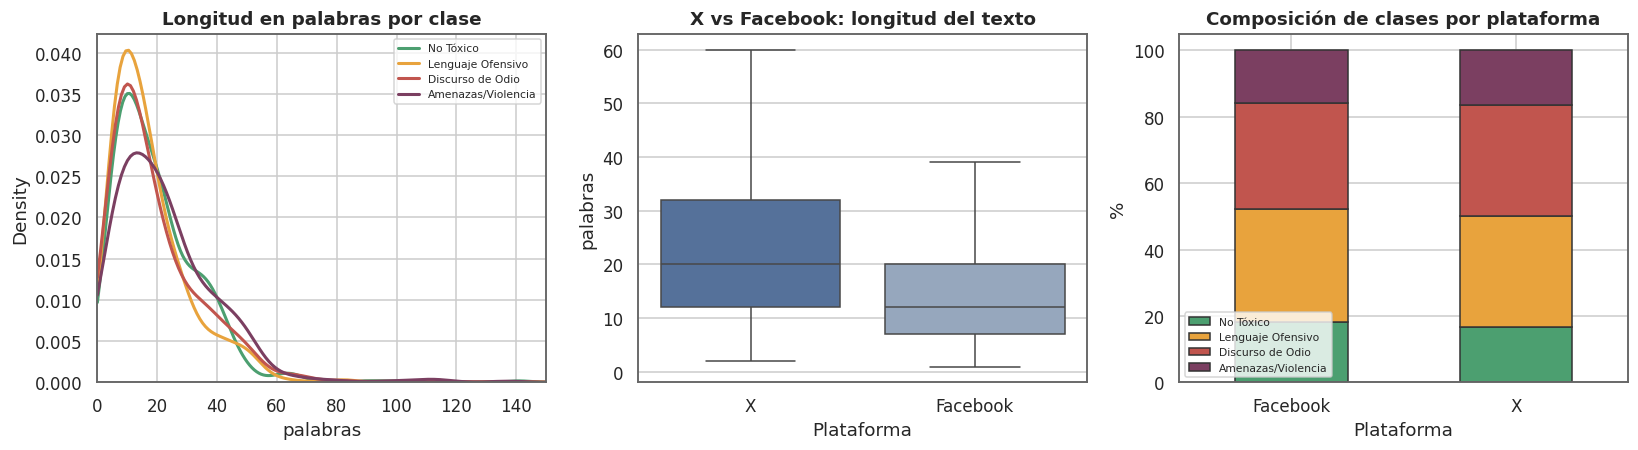

            mean   50%    max
Plataforma                   
Facebook    17.2  12.0  231.0
X           23.0  20.0  143.0


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for c in CLASES_CANONICAS:
    d_ = sub[sub["clase"] == c]["n_palabras"]
    if len(d_):
        sns.kdeplot(d_, ax=axes[0], label=c, color=PALETA[c], lw=2, clip=(0, 200))
axes[0].set_title("Longitud en palabras por clase")
axes[0].set_xlabel("palabras"); axes[0].set_xlim(0, 150); axes[0].legend(fontsize=7)

sns.boxplot(data=sub, x="Plataforma", y="n_palabras", ax=axes[1],
            palette=["#4A6FA5", "#8FA6C4"], showfliers=False)
axes[1].set_title("X vs Facebook: longitud del texto")
axes[1].set_ylabel("palabras")

ct = pd.crosstab(sub["Plataforma"], sub["clase"], normalize="index").mul(100)
ct = ct.reindex(columns=CLASES_CANONICAS)
ct.plot(kind="bar", stacked=True, ax=axes[2],
        color=[PALETA[c] for c in ct.columns], edgecolor="#333")
axes[2].set_title("Composición de clases por plataforma")
axes[2].set_ylabel("%"); axes[2].tick_params(axis="x", rotation=0)
axes[2].legend(fontsize=7, loc="lower left")
plt.tight_layout()
guardar(fig, "04_perfil_linguistico")
plt.show()

print(sub.groupby("Plataforma")["n_palabras"].describe()[["mean", "50%", "max"]].round(1))

In [22]:
# ¿Coincide 'Lenguaje_Dialectal' con la realidad? Se contrasta contra el léxico.
terminos = set(lexico["Texto_Original"].astype(str).str.lower().str.strip())
terminos = {t_ for t_ in terminos if len(t_) > 2}

def cuenta_jerga(s):
    palabras = set(re.findall(r"\w+", str(s).lower()))
    return len(palabras & terminos)

sub_j = sub.copy()
sub_j["n_jerga"] = sub_j["Texto_Original"].apply(cuenta_jerga)

print("Marcado como dialecto en la anotación:")
print(corpus["Lenguaje_Dialectal"].value_counts().head(6).to_string())
print("\nTérminos del léxico salvadoreño realmente presentes, según esa marca:")
print(sub_j.groupby("Lenguaje_Dialectal")["n_jerga"]
      .agg(["mean", "median", "count"]).round(2).sort_values("count", ascending=False).head(6).to_string())

Marcado como dialecto en la anotación:
Lenguaje_Dialectal
Español Estándar    1762
Salvadoreño         1338
Código-Mezclado        2
Peruano                1
Colombiano             1

Términos del léxico salvadoreño realmente presentes, según esa marca:
                    mean  median  count
Lenguaje_Dialectal                     
Español Estándar    1.03     1.0   1759
Salvadoreño         1.18     1.0   1334
Código-Mezclado     0.50     0.5      2
Colombiano          2.00     2.0      1
Peruano             1.00     1.0      1


> **Observación sobre `Lenguaje_Dialectal`.** Si los textos marcados como "Español
> Estándar" contienen tanta jerga local como los marcados "Salvadoreño", la variable
> está capturando criterio del anotador y no una propiedad del texto. En ese caso no
> debe usarse como *feature* ni como eje de estratificación; sí conviene revisar su
> definición en la guía de anotación.

## 8. Tokenización: qué implica para mBERT y XLM-R

Decisión concreta a tomar aquí: el valor de `max_length`. Afecta directamente al
coste de entrenamiento (la atención escala O(n²)) y al riesgo de truncar contenido.

In [23]:
info_tok = None
try:
    from transformers import AutoTokenizer
    toks = {
        "mBERT": AutoTokenizer.from_pretrained("bert-base-multilingual-cased"),
        "XLM-R": AutoTokenizer.from_pretrained("xlm-roberta-base"),
    }
    textos_modelo = sub["Texto_Original"].apply(normalizar).tolist()

    filas = []
    for nombre, tk in toks.items():
        largos = [len(tk.encode(t_, add_special_tokens=True)) for t_ in textos_modelo]
        s = pd.Series(largos)
        filas.append({
            "modelo": nombre,
            "vocab": tk.vocab_size,
            "media": round(s.mean(), 1),
            "p50": int(s.quantile(.50)),
            "p95": int(s.quantile(.95)),
            "p99": int(s.quantile(.99)),
            "max": int(s.max()),
            "%_sobre_128": round((s > 128).mean() * 100, 2),
            "%_sobre_256": round((s > 256).mean() * 100, 2),
        })
    info_tok = pd.DataFrame(filas)
    display(info_tok)
except Exception as e:
    print("Sin acceso a Hugging Face en este entorno — ejecutar en Colab.")
    print("Estimación provisional a partir de caracteres (≈ 1 token / 3.5 chars en español):")
    est = (sub["n_chars"] / 3.5 + 2)
    print(est.describe(percentiles=[.5, .95, .99]).round(1).to_string())
    print(f"\n% de textos que superarían 128 tokens: {(est > 128).mean()*100:.2f}%")

Sin acceso a Hugging Face en este entorno — ejecutar en Colab.
Estimación provisional a partir de caracteres (≈ 1 token / 3.5 chars en español):
count    3097.0
mean       34.8
std        29.5
min         4.0
50%        26.9
95%        79.8
99%       126.4
max       430.6

% de textos que superarían 128 tokens: 1.00%


### Elección de `max_length`

El criterio es cubrir el percentil 95–99 sin pagar padding innecesario. Con textos
cuya mediana ronda las 88 caracteres y un p99 muy por debajo del límite de 512 de
ambos modelos:

- **`max_length = 128`** cubre la práctica totalidad del corpus y es el punto
  eficiente. Recomendado como configuración base.
- **`max_length = 256`** solo si el análisis empírico muestra que los comentarios
  largos de Facebook se truncan de forma significativa.
- Usar 512 sería desperdiciar cómputo: la atención escala cuadráticamente, y pasar de
  128 a 512 multiplica por ~16 el coste de esa capa sin ganancia.

**Padding dinámico por lote** (`DataCollatorWithPadding`) en lugar de padding fijo:
reduce el cómputo real sin afectar el resultado.

### Diferencias entre los dos modelos, relevantes para la comparación

| | mBERT | XLM-R |
|---|---|---|
| Vocabulario | ~119k WordPiece | ~250k SentencePiece |
| Preentrenamiento | Wikipedia, 104 idiomas | CommonCrawl (CC-100), 100 idiomas, ~2 TB |
| Español en el corpus | Wikipedia en español | Web en español, mucho mayor volumen |
| Registro coloquial | Escaso — Wikipedia es formal | Abundante — la web sí lo tiene |
| Tildes | Solo la variante **cased** las conserva | Siempre |
| Emojis | Cobertura casi nula | Parcial |
| Tokens por texto en español | Más (vocabulario menor) | Menos |

**Predicción del proyecto:** XLM-R debería superar a mBERT en este corpus, porque el
registro (jerga, coloquialismos, deformación ortográfica) está mucho mejor
representado en CommonCrawl que en Wikipedia. El *ablation study* de la Etapa II debe
confirmarlo o refutarlo — y si lo refuta, eso también es un resultado publicable.

> **Requisito operativo:** usar `bert-base-multilingual-cased`, **no** la variante
> *uncased*. La *uncased* aplica `strip_accents=True` y destruiría las tildes de
> forma silenciosa, dentro del propio tokenizador, contradiciendo todo lo decidido en
> la sección 7.

## 9. Acuerdo entre anotadores (Cohen's Kappa)

El perfil del proyecto fija **κ ≥ 0.60** como umbral de calidad. Hoy el corpus tiene
**0 filas validadas** y la columna `Cohen_Kappa` está vacía en su totalidad. Es la
brecha metodológica más seria del dataset: sin acuerdo medido, no hay evidencia de que
las etiquetas sean reproducibles, y un jurado lo señalará.

Esta sección deja preparados (a) el cálculo y (b) la muestra a doble-anotar.

In [24]:
print("Estado de validación:")
for c in ["Validado", "Validador", "Cohen_Kappa", "Acuerdo_Validador"]:
    print(f"  {c:<22} no nulos: {corpus[c].notna().sum():>5}  /  {len(corpus)}")

Estado de validación:
  Validado               no nulos:  3104  /  3104
  Validador              no nulos:     0  /  3104
  Cohen_Kappa            no nulos:     0  /  3104
  Acuerdo_Validador      no nulos:     0  /  3104


In [25]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix

def kappa_por_pares(df, col_anotador, col_item, col_clase):
    '''Cohen's Kappa por cada par de anotadores sobre los ítems que ambos anotaron.'''
    salida = []
    anotadores = sorted(df[col_anotador].dropna().unique())
    for i, a in enumerate(anotadores):
        for b in anotadores[i + 1:]:
            da = df[df[col_anotador] == a].set_index(col_item)[col_clase]
            db = df[df[col_anotador] == b].set_index(col_item)[col_clase]
            comunes = da.index.intersection(db.index)
            if len(comunes) < 10:
                continue
            k = cohen_kappa_score(da.loc[comunes], db.loc[comunes])
            salida.append({"anotador_a": a, "anotador_b": b,
                           "n_items": len(comunes), "kappa": round(k, 3)})
    return pd.DataFrame(salida)

def interpretar_kappa(k):
    '''Escala de Landis & Koch (1977).'''
    if k < 0.00: return "pobre"
    if k < 0.20: return "leve"
    if k < 0.40: return "aceptable"
    if k < 0.60: return "moderado"
    if k < 0.80: return "sustancial"
    return "casi perfecto"

print("Funciones listas. Se aplicarán cuando exista doble anotación.")

Funciones listas. Se aplicarán cuando exista doble anotación.


In [26]:
# --- Muestra estratificada para la ronda de doble anotación ---
# Regla práctica: 10-20% del corpus, estratificado por clase y plataforma.
FRACCION = 0.15

muestra = (sub.groupby(["clase", "Plataforma"], group_keys=False)
              .apply(lambda g: g.sample(max(1, int(len(g) * FRACCION)), random_state=SEED)))

# Se asigna como segundo anotador alguien distinto de quien anotó originalmente.
equipo = sorted(corpus["Responsable"].dropna().unique())
def otro(r):
    cand = [x for x in equipo if x != r]
    return cand[hash(r) % len(cand)]

plantilla = muestra[["ID", "Plataforma", "Texto_Original", "Responsable", "clase", "subclase"]].copy()
plantilla = plantilla.rename(columns={"Responsable": "anotador_1", "clase": "clase_anotador_1"})
plantilla["anotador_2"] = plantilla["anotador_1"].apply(otro)
plantilla["clase_anotador_2"] = ""        # <- a completar a ciegas
plantilla["subclase_anotador_2"] = ""
plantilla["notas_desacuerdo"] = ""
plantilla = plantilla.sample(frac=1, random_state=SEED)   # orden aleatorio

plantilla.to_csv(INTERIM / "plantilla_doble_anotacion.csv", index=False, encoding="utf-8-sig")
print(f"muestra de {len(plantilla)} ítems ({FRACCION:.0%} del corpus)")
print(f"-> data/interim/plantilla_doble_anotacion.csv")
print("\nCarga por anotador 2:")
print(plantilla["anotador_2"].value_counts().to_string())
display(plantilla.head(4))

muestra de 460 ítems (15% del corpus)
-> data/interim/plantilla_doble_anotacion.csv

Carga por anotador 2:
anotador_2
Cristian    300
Willian     160


,ID,Plataforma,Texto_Original,anotador_1,clase_anotador_1,subclase,anotador_2,clase_anotador_2,subclase_anotador_2,notas_desacuerdo
2577,2578,Facebook,Chapines serotes get out here,Julio,Discurso de Odio,Estigmatización nacional,Cristian,,,
954,955,Facebook,Anonymous participant 218 Bueno pues Aqui ya h...,Willian,Amenazas/Violencia,Deseo de Daño/Sufrimiento,Cristian,,,
3074,3075,X,Y porque omites a los pvt0z judíos de MIERDA?,Julio,Discurso de Odio,Antisemitismo,Cristian,,,
73,74,X,#Nacionales | Pronóstico para el martes: ambie...,Willian,No Tóxico,N/A,Cristian,,,


### Protocolo recomendado

1. **Corregir primero la guía de anotación.** La divergencia detectada en la sección 3
   es de protocolo. Si se mide κ antes de unificar el criterio, se medirá confusión
   sobre las reglas, no desacuerdo genuino.
2. El anotador 2 etiqueta **a ciegas** — la columna `clase_anotador_1` debe ocultarse
   antes de repartir el archivo.
3. Calcular κ **global y por clase**. Un κ global aceptable puede ocultar un κ pésimo
   en `Amenazas/Violencia`, que es la clase crítica.
4. Resolver los desacuerdos por **adjudicación de un tercero**, no promediando.
5. Reportar κ en el documento final. Si κ < 0.60, refinar la guía y repetir sobre una
   muestra nueva.

**Qué esperar:** en detección de discurso de odio, κ entre 0.45 y 0.70 es lo habitual
en la literatura. HatEval reportó valores en ese rango. Sarcasmo e ironía son los focos
sistemáticos de desacuerdo — y este corpus tiene columnas específicas para ambos, lo
cual conviene aprovechar en el análisis de errores.

## 10. Limpieza final y construcción de los *splits*

Orden deliberado de las operaciones:

1. Descartar filas apartadas para revisión manual.
2. Deduplicar (**antes** del *split*, o el mismo texto aparecería en train y test).
3. Generar las tres variantes de texto.
4. Agrupar por autor (*group split*) para evitar fuga de estilo.
5. Estratificar por clase.

In [27]:
df = sub.copy()
print(f"partida (con clase asignada): {len(df):,}")

# --- Deduplicación ---
clave = (df["Texto_Original"].astype(str).str.normalize("NFKC").str.lower()
         .str.replace(r"\s+", " ", regex=True).str.strip())
df = df.assign(_k=clave)

conflictivos = df.groupby("_k")["clase"].nunique()
conflictivos = set(conflictivos[conflictivos > 1].index)
print(f"duplicados con etiqueta contradictoria (se descartan): "
      f"{df['_k'].isin(conflictivos).sum()}")
df = df[~df["_k"].isin(conflictivos)]

antes_dedup = len(df)
df = df.drop_duplicates(subset="_k", keep="first").drop(columns="_k")
print(f"duplicados eliminados: {antes_dedup - len(df)}")
print(f"tras deduplicar: {len(df):,}")

# --- Textos ---
df["texto_original"] = df["Texto_Original"].astype(str)
df["texto_modelo"]   = df["texto_original"].apply(normalizar)          # producción
df["texto_agresivo"] = df["texto_original"].apply(normalizar_agresivo) # control ablación
df["label"] = df["clase"].map(LABEL2ID)

vacios = (df["texto_modelo"].str.strip() == "").sum()
print(f"textos que quedan vacíos tras normalizar: {vacios}")
df = df[df["texto_modelo"].str.strip() != ""]

print(f"\nfinal: {len(df):,}")
print(df["clase"].value_counts().reindex(CLASES_CANONICAS).to_string())

partida (con clase asignada): 3,097
duplicados con etiqueta contradictoria (se descartan): 0
duplicados eliminados: 40
tras deduplicar: 3,057


textos que quedan vacíos tras normalizar: 0

final: 3,057
clase
No Tóxico              537
Lenguaje Ofensivo     1036
Discurso de Odio       983
Amenazas/Violencia     501


In [28]:
from sklearn.model_selection import train_test_split

# --- Fuga por autor ---
# Si un mismo usuario aparece en train y en test, el modelo puede memorizar estilo.
conc = df["Usuario_ID_Anonimizado"].value_counts()
print(f"usuarios con más de una publicación: {(conc > 1).sum()}")
print(f"máximo de publicaciones por usuario: {conc.max()}")

usa_grupos = (conc > 1).sum() > 0.05 * df["Usuario_ID_Anonimizado"].nunique()
print(f"\n¿aplicar split por grupos de autor?: {usa_grupos}")

usuarios con más de una publicación: 0
máximo de publicaciones por usuario: 1

¿aplicar split por grupos de autor?: False


In [29]:
# 70 / 15 / 15 estratificado por clase
tr, tmp = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=SEED)
va, te  = train_test_split(tmp, test_size=0.50, stratify=tmp["label"], random_state=SEED)

for nombre, d_ in [("train", tr), ("val", va), ("test", te)]:
    print(f"{nombre:<6} {len(d_):>5}  ({len(d_)/len(df)*100:4.1f}%)   "
          + "  ".join(f"{c[:12]}={(d_['clase']==c).sum():>4}" for c in CLASES_CANONICAS))

# Verificación de no solapamiento
assert not (set(tr.ID) & set(va.ID)), "fuga train/val"
assert not (set(tr.ID) & set(te.ID)), "fuga train/test"
assert not (set(va.ID) & set(te.ID)), "fuga val/test"
print("\nsin solapamiento de IDs entre splits")

train   2139  (70.0%)   No Tóxico= 376  Lenguaje Ofe= 725  Discurso de = 688  Amenazas/Vio= 350
val      459  (15.0%)   No Tóxico=  80  Lenguaje Ofe= 156  Discurso de = 147  Amenazas/Vio=  76
test     459  (15.0%)   No Tóxico=  81  Lenguaje Ofe= 155  Discurso de = 148  Amenazas/Vio=  75

sin solapamiento de IDs entre splits


In [30]:
# --- Pesos de clase para CrossEntropyLoss ---
from sklearn.utils.class_weight import compute_class_weight

pesos = compute_class_weight("balanced",
                             classes=np.arange(len(CLASES_CANONICAS)),
                             y=tr["label"].values)
pesos_dict = {ID2LABEL[i]: round(float(w), 4) for i, w in enumerate(pesos)}
print("Pesos de clase (calculados SOLO sobre train):")
for k, v in pesos_dict.items():
    print(f"  {k:<20} {v}")

print("\nUso en el entrenamiento:")
print("  loss_fn = torch.nn.CrossEntropyLoss(weight=torch.tensor(pesos, dtype=torch.float))")

Pesos de clase (calculados SOLO sobre train):
  No Tóxico            1.4222
  Lenguaje Ofensivo    0.7376
  Discurso de Odio     0.7773
  Amenazas/Violencia   1.5279

Uso en el entrenamiento:
  loss_fn = torch.nn.CrossEntropyLoss(weight=torch.tensor(pesos, dtype=torch.float))


In [31]:
COLS = ["ID", "Plataforma", "Responsable", "fecha", "hash_origen",
        "Usuario_ID_Anonimizado", "texto_original", "texto_modelo", "texto_agresivo",
        "clase", "label", "subclase", "Grupos_Afectados", "Lenguaje_Dialectal",
        "Presencia_Sarcasmo", "Presencia_Ironia", "Contexto_Politico",
        "n_chars", "n_palabras", "n_emojis", "n_menciones", "n_urls", "n_hashtags"]

for nombre, d_ in [("train", tr), ("val", va), ("test", te)]:
    salida = d_[COLS].copy()
    ruta = PROCESSED / f"{nombre}.csv"
    salida.to_csv(ruta, index=False, encoding="utf-8-sig")
    print(f"{ruta.relative_to(ROOT)}  ({len(salida):,} filas)")

df[COLS].to_csv(PROCESSED / "corpus_limpio.csv", index=False, encoding="utf-8-sig")
print(f"{(PROCESSED / 'corpus_limpio.csv').relative_to(ROOT)}  ({len(df):,} filas)")

data/processed/train.csv  (2,139 filas)
data/processed/val.csv  (459 filas)


data/processed/test.csv  (459 filas)


data/processed/corpus_limpio.csv  (3,057 filas)


In [32]:
meta = {
    "generado": pd.Timestamp.now().isoformat(timespec="seconds"),
    "semilla": SEED,
    "filas_crudas": int(len(corpus)),
    "filas_finales": int(len(df)),
    "apartadas_revision_manual": int(corpus["revisar_manual"].sum()),
    "clases": CLASES_CANONICAS,
    "label2id": LABEL2ID,
    "distribucion": df["clase"].value_counts().to_dict(),
    "splits": {"train": len(tr), "val": len(va), "test": len(te)},
    "pesos_clase": pesos_dict,
    "campo_texto_recomendado": "texto_modelo",
    "normalizacion": {
        "modulo": "src/features/normalization.py",
        "preserva": ["tildes", "mayúsculas", "puntuación", "ortografía original"],
        "aplica": ["Unicode NFC", "ftfy", "quitar invisibles",
                   "colapsar espacios", "placeholders PII", "demojización a español"],
    },
    "modelos_objetivo": {
        "mbert": "bert-base-multilingual-cased",
        "xlmr": "xlm-roberta-base",
        "max_length_recomendado": 128,
        "nota": "usar la variante CASED de mBERT; la uncased elimina tildes",
    },
    "pendientes": [
        "Resolver cola_revision_etiquetas.csv (7 filas)",
        "Ronda de doble anotación y cálculo de Cohen's Kappa (umbral 0.60)",
        "Recolección dirigida de Amenazas/Violencia hasta >= 480",
        "Reparar codificación de lexicon_emojis.csv",
        "Unificar la guía de anotación antes de medir Kappa",
    ],
}
with open(PROCESSED / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2, default=str)
print(json.dumps(meta, ensure_ascii=False, indent=2, default=str)[:1400])

{
  "generado": "2026-07-30T16:35:24",
  "semilla": 42,
  "filas_crudas": 3104,
  "filas_finales": 3057,
  "apartadas_revision_manual": 7,
  "clases": [
    "No Tóxico",
    "Lenguaje Ofensivo",
    "Discurso de Odio",
    "Amenazas/Violencia"
  ],
  "label2id": {
    "No Tóxico": 0,
    "Lenguaje Ofensivo": 1,
    "Discurso de Odio": 2,
    "Amenazas/Violencia": 3
  },
  "distribucion": {
    "Lenguaje Ofensivo": 1036,
    "Discurso de Odio": 983,
    "No Tóxico": 537,
    "Amenazas/Violencia": 501
  },
  "splits": {
    "train": 2139,
    "val": 459,
    "test": 459
  },
  "pesos_clase": {
    "No Tóxico": 1.4222,
    "Lenguaje Ofensivo": 0.7376,
    "Discurso de Odio": 0.7773,
    "Amenazas/Violencia": 1.5279
  },
  "campo_texto_recomendado": "texto_modelo",
  "normalizacion": {
    "modulo": "src/features/normalization.py",
    "preserva": [
      "tildes",
      "mayúsculas",
      "puntuación",
      "ortografía original"
    ],
    "aplica": [
      "Unicode NFC",
      "ftfy",


figura guardada -> reports/figures/05_pipeline_y_splits.png


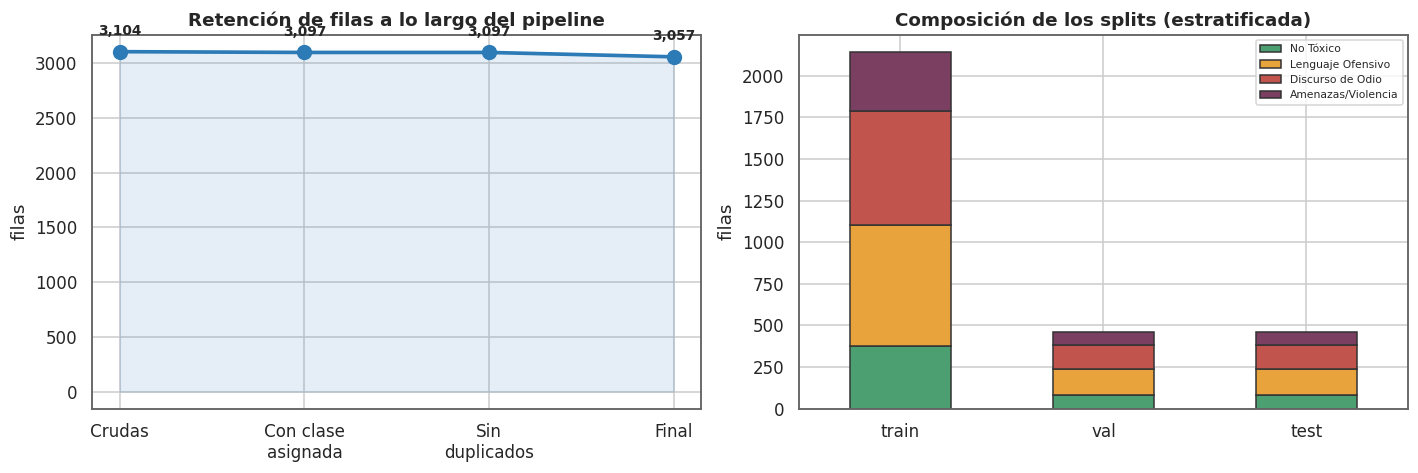

In [33]:
# --- Figura resumen del pipeline ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

etapas = ["Crudas", "Con clase\nasignada", "Sin\nduplicados", "Final"]
valores = [len(corpus), int((~corpus["revisar_manual"]).sum()), antes_dedup, len(df)]
axes[0].plot(etapas, valores, "o-", color="#2C7BB6", lw=2.4, ms=9)
axes[0].fill_between(range(len(etapas)), valores, alpha=0.12, color="#2C7BB6")
axes[0].set_title("Retención de filas a lo largo del pipeline")
axes[0].set_ylabel("filas")
for i, v in enumerate(valores):
    axes[0].annotate(f"{v:,}", (i, v), textcoords="offset points",
                     xytext=(0, 11), ha="center", fontsize=9, fontweight="bold")

comp = pd.DataFrame({
    "train": tr["clase"].value_counts(),
    "val":   va["clase"].value_counts(),
    "test":  te["clase"].value_counts(),
}).reindex(CLASES_CANONICAS)
comp.T.plot(kind="bar", stacked=True, ax=axes[1],
            color=[PALETA[c] for c in comp.index], edgecolor="#333")
axes[1].set_title("Composición de los splits (estratificada)")
axes[1].set_ylabel("filas"); axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(fontsize=7)
plt.tight_layout()
guardar(fig, "05_pipeline_y_splits")
plt.show()

## 11. Resumen de decisiones y trabajo pendiente

### Decisiones tomadas

| Aspecto | Decisión | Justificación |
|---|---|---|
| Tildes y ñ | **Se conservan** | Distintivas en español; mBERT-cased y XLM-R las modelan |
| Mayúsculas | **Se conservan** | Señal de énfasis/agresión; los modelos son *cased* |
| Ortografía | **No se corrige** | Es señal (evasión de moderación) y evita *train/serve skew* |
| Puntuación | **Se conserva** | Los tokenizadores subword la aprovechan |
| Stopwords / lematización | **No se aplican** | Receta de bolsa de palabras; destruye la sintaxis que usa la atención |
| Espacios y NFC | **Se normalizan** | No lingüístico; protege frente a entrada de producción |
| Emojis | **Demojizar a español** | Evita `[UNK]` en mBERT; iguala la comparación; consistente con RoBERTuito |
| Tono de piel | **Se elimina** | 🖕🏼 ≡ 🖕🏾; solo dispersa la señal |
| @menciones | **`@usuario`** | Anonimiza pero preserva la señal "ataque dirigido" |
| URLs en el texto | **`http://url`** | Ídem |
| `URL_Original` | **Fuera del dataset público** | Contiene el *handle* real: anula la seudonimización |
| Etiquetas | **16 → 4 con mapeo documentado** | Divergencia de protocolo, no error de tipeo |
| Casos ambiguos | **Revisión humana** | 7 filas; no contaminar clases minoritarias |
| Desbalance | **`class_weight` en la pérdida** | Sin coste de datos; el remuestreo solo sobre train |
| `max_length` | **128** | Cubre el p99; la atención escala O(n²) |

### Artefactos generados

```
data/interim/
  cola_revision_etiquetas.csv      7 filas para resolver a mano
  plantilla_doble_anotacion.csv    muestra estratificada para medir Kappa
  mapa_procedencia.csv             ID -> URL real  (NO versionar)

data/processed/
  corpus_limpio.csv                dataset completo
  train.csv / val.csv / test.csv   splits estratificados 70/15/15
  metadata.json                    trazabilidad y configuración

reports/figures/                   5 figuras para el documento
```

### Pendientes antes de entrenar

1. **Unificar la guía de anotación** y resolver las 7 filas apartadas.
2. **Ronda de doble anotación** con `plantilla_doble_anotacion.csv` y reportar κ.
   Sin esto, la calidad del corpus no está demostrada.
3. **Recolección dirigida de `Amenazas/Violencia`** hasta alcanzar ≥ 480 ejemplos.
4. **Reparar `lexicon_emojis.csv`** (codificación y cabecera).
5. **Descargar los datasets públicos** a `data/external/` para el *fine-tuning* de
   primera etapa (HatEval, Spanish Hate Speech Superset, DETOXIS, TextDetox).

### Enlace con la fase de modelado

El dataset se exporta con tres variantes de texto precisamente para que el
preprocesamiento sea **medible** y no una decisión de autoridad:

| Campo | Uso |
|---|---|
| `texto_modelo` | Entrenamiento y producción. **Es el campo por defecto.** |
| `texto_agresivo` | Grupo de control del *ablation study* |
| `texto_original` | Trazabilidad y análisis cualitativo de errores |

El estudio de ablación de la Etapa II debe reportar el F1-macro de cada variante en
mBERT y en XLM-R. Ese cuadro de cuatro celdas convierte "decidimos no quitar tildes"
en un resultado experimental — que es lo que sostiene la decisión ante un jurado.